In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score,
    confusion_matrix, precision_recall_curve, roc_curve,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# ML Algorithm
#%pip install xgboost lightgbm
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression

In [3]:
d = pd.read_csv("/content/health_fitness_dataset.csv")
d.shape

(18593, 22)

In [4]:
d.head(10)

,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,...,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,health_condition,smoking_status,fitness_level
0,1,2024-01-01,56,F,165.3,53.7,Dancing,41,Low,3.3,...,3,7128,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.04
1,1,2024-01-04,56,F,165.3,53.9,Swimming,28,Low,2.9,...,7,7925,1.8,19.6,69.5,110.7,72.9,NaN,Never,0.07
2,1,2024-01-05,56,F,165.3,54.2,Swimming,21,Medium,2.6,...,7,7557,2.7,19.6,69.5,110.7,72.9,NaN,Never,0.09
3,1,2024-01-07,56,F,165.3,54.4,Weight Training,99,Medium,10.7,...,8,11120,2.6,19.6,69.5,110.7,72.9,NaN,Never,0.21
4,1,2024-01-09,56,F,165.3,54.7,Swimming,100,Medium,12.7,...,1,5406,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.33
5,1,2024-01-10,56,F,165.3,54.9,HIIT,31,Medium,6.8,...,10,10202,2.2,19.6,69.5,110.7,72.9,NaN,Never,0.37
6,1,2024-01-11,56,F,165.3,55.2,Weight Training,97,High,12.4,...,8,5912,2.8,19.6,69.5,110.7,72.9,NaN,Never,0.51
7,1,2024-01-12,56,F,165.3,55.5,HIIT,70,Low,12.9,...,7,9477,1.6,19.6,69.5,110.7,72.9,NaN,Never,0.58
8,1,2024-01-17,56,F,165.3,55.7,HIIT,89,Medium,19.7,...,7,9710,3.3,19.6,69.5,110.7,72.9,NaN,Never,0.68
9,1,2024-01-18,56,F,165.3,56.0,Weight Training,115,Medium,12.8,...,3,7830,2.0,19.6,69.5,110.7,72.9,NaN,Never,0.82


In [5]:
d.tail(10)

,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,...,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,health_condition,smoking_status,fitness_level
18583,82,2024-03-12,36,M,169.9,72.1,Basketball,30,Medium,5.7,...,6,11726,2.3,21.4,70.6,126.0,88.3,NaN,Never,3.04
18584,82,2024-03-14,36,M,169.9,72.4,Basketball,25,Low,4.0,...,2,9131,1.7,21.4,70.6,126.0,88.3,NaN,Never,3.06
18585,82,2024-03-15,36,M,169.9,72.6,Walking,42,Low,3.2,...,3,8766,2.5,21.4,70.6,126.0,88.3,NaN,Never,3.10
18586,82,2024-03-16,36,M,169.9,72.9,Basketball,108,High,24.4,...,4,10103,1.5,21.4,70.6,126.0,88.3,NaN,Never,3.25
18587,82,2024-03-17,36,M,169.9,73.1,Yoga,111,Low,6.7,...,4,9699,2.0,21.4,70.6,126.0,88.3,NaN,Never,3.37
18588,82,2024-03-20,36,M,169.9,73.4,Basketball,40,Medium,7.8,...,1,10557,1.6,21.4,70.6,126.0,88.3,NaN,Never,3.41
18589,82,2024-03-21,36,M,169.9,73.7,HIIT,80,High,27.4,...,2,10834,3.3,21.4,70.6,126.0,88.3,NaN,Never,3.53
18590,82,2024-03-22,36,M,169.9,73.9,Yoga,74,High,6.4,...,4,7128,3.3,21.4,70.6,126.0,88.3,NaN,Never,3.63
18591,82,2024-03-23,36,M,169.9,74.2,HIIT,72,Medium,21.3,...,3,14495,2.5,21.4,70.6,126.0,88.3,NaN,Never,3.72
18592,82,2024-03-24,36,M,169.9,74.4,Yoga,100,High,8.7,...,4,10460,1.6,21.4,7.0,NaN,NaN,NaN,NaN,NaN


In [6]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18593 entries, 0 to 18592
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   participant_id            18593 non-null  int64  
 1   date                      18593 non-null  object 
 2   age                       18593 non-null  int64  
 3   gender                    18593 non-null  object 
 4   height_cm                 18593 non-null  float64
 5   weight_kg                 18593 non-null  float64
 6   activity_type             18593 non-null  object 
 7   duration_minutes          18593 non-null  int64  
 8   intensity                 18593 non-null  object 
 9   calories_burned           18593 non-null  float64
 10  avg_heart_rate            18593 non-null  int64  
 11  hours_sleep               18593 non-null  float64
 12  stress_level              18593 non-null  int64  
 13  daily_steps               18593 non-null  int64  
 14  hydrat

In [7]:
d.describe()

,participant_id,age,height_cm,weight_kg,duration_minutes,calories_burned,avg_heart_rate,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,fitness_level
count,18593.000000,18593.000000,18593.000000,18593.000000,18593.000000,18593.000000,18593.000000,18593.000000,18593.000000,18593.000000,18593.000000,18593.000000,18593.000000,18592.000000,18592.000000,18592.000000
mean,41.321196,43.074867,169.470575,96.279901,70.066261,15.648986,130.381165,7.051358,5.247136,8629.834884,2.495186,23.047873,70.665186,121.296622,79.226388,9.533507
std,23.472078,14.195134,9.251596,22.302124,29.243486,10.188914,18.051367,0.972273,2.767697,2057.230116,0.578999,3.582110,5.708584,9.215892,7.967888,5.506512
min,1.000000,18.000000,150.600000,45.300000,20.000000,1.100000,86.000000,4.000000,1.000000,1098.000000,1.500000,15.100000,7.000000,78.000000,64.400000,0.020000
25%,21.000000,31.000000,162.900000,79.500000,45.000000,7.900000,117.000000,6.400000,3.000000,7205.000000,2.000000,20.800000,67.300000,116.700000,72.700000,4.790000
50%,41.000000,45.000000,169.200000,95.900000,70.000000,13.300000,129.000000,7.000000,5.000000,8611.000000,2.500000,22.500000,71.000000,120.600000,79.400000,9.510000
75%,62.000000,55.000000,177.500000,111.800000,95.000000,21.100000,143.000000,7.700000,8.000000,10030.000000,3.000000,25.700000,74.200000,126.700000,85.400000,14.260000
max,82.000000,64.000000,189.300000,167.900000,120.000000,76.200000,202.000000,10.000000,10.000000,15918.000000,3.500000,32.000000,85.600000,140.700000,100.000000,20.840000


In [8]:
d.isnull().sum()

,0
participant_id,0
date,0
age,0
gender,0
height_cm,0
weight_kg,0
activity_type,0
duration_minutes,0
intensity,0
calories_burned,0


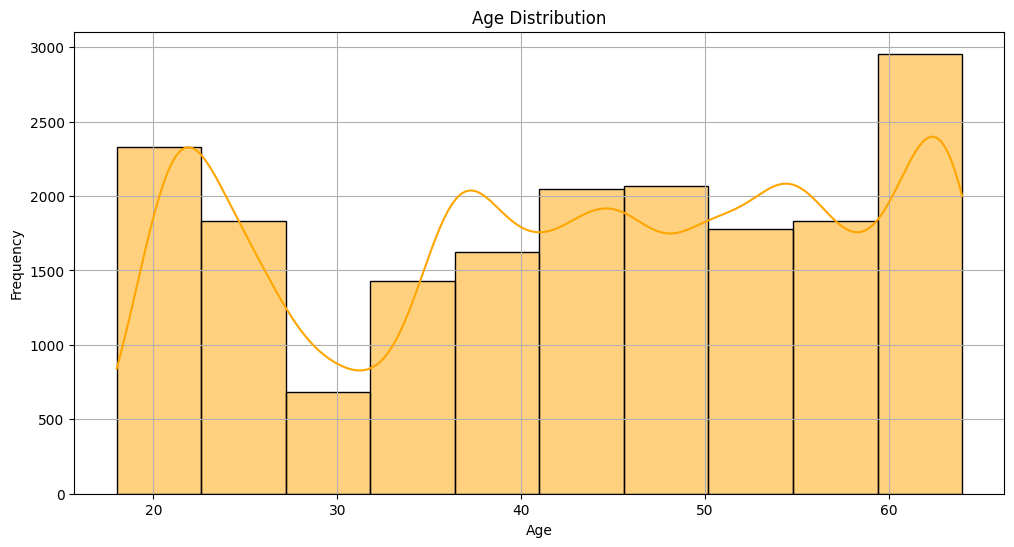

In [9]:
# Plot age distribution
plt.figure(figsize=(12, 6))
sns.histplot(data=d, x='age', bins=10, kde=True, color='orange')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

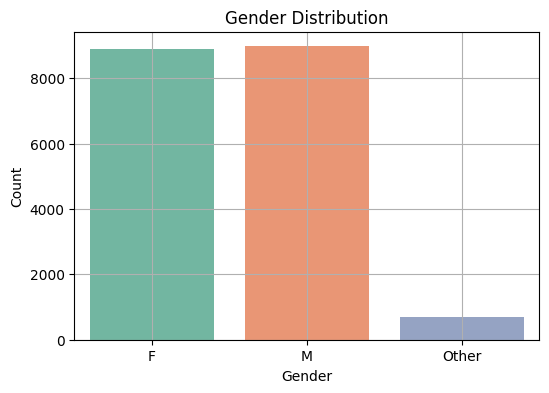

In [10]:
# Plot gender distribution
plt.figure(figsize=(6, 4))
sns.countplot(d, x='gender',hue='gender',legend=False, palette='Set2')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.grid(True)
plt.show()

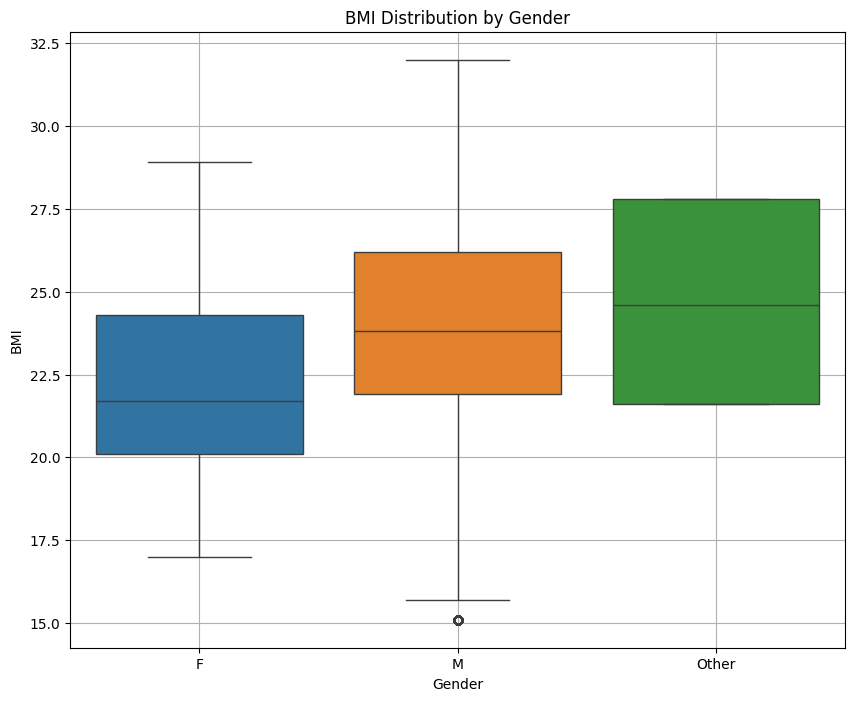

In [11]:
# BMI Distribution by Gender
plt.figure(figsize=(10, 8))
#plt.subplot(1, 1, 1)
sns.boxplot(data=d, x='gender', y='bmi',hue='gender')
plt.title('BMI Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('BMI')
plt.grid(True)
plt.show()


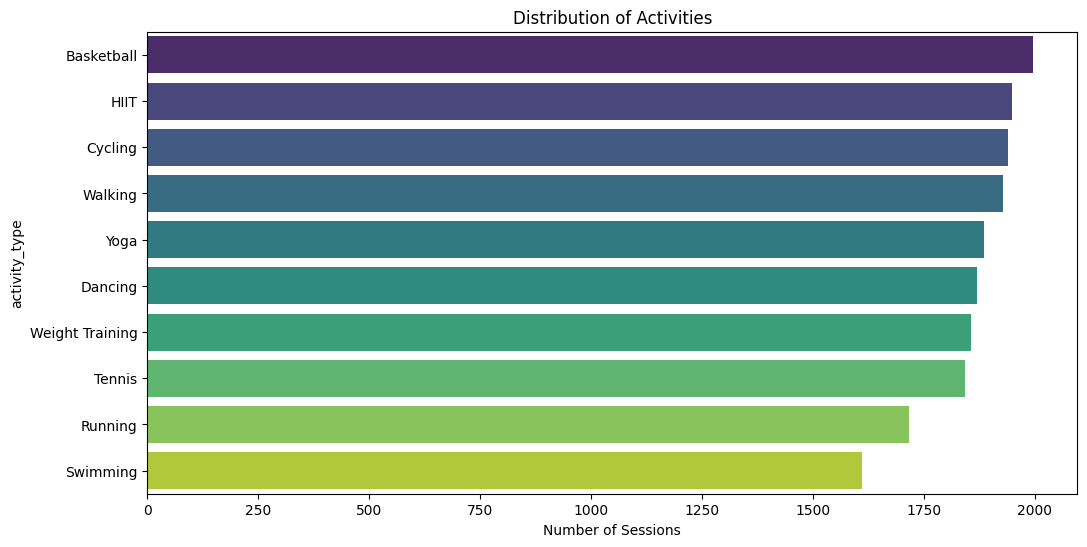

In [12]:
# Activity Distribution
plt.figure(figsize=(12, 6))
activity_counts = d['activity_type'].value_counts()
sns.barplot(x=activity_counts.values, y=activity_counts.index,hue=activity_counts.index,dodge=False,legend=False, palette='viridis')
plt.title('Distribution of Activities')
plt.xlabel('Number of Sessions')
plt.show()

### Encodeing dataset and cleaning for model prediction

In [13]:
df = d.copy()

In [14]:
# Encoding, 0= No health condition, 1 = Has a health condition
df['health_condition'] = df['health_condition'].apply(lambda x: 0 if pd.isna(x) else 1)
print(d['health_condition'].value_counts())

health_condition
Hypertension    3845
Diabetes        1598
Asthma           452
Name: count, dtype: int64


In [15]:
# droping missing value before mapping
df = df.dropna(subset= ['gender'])

In [16]:
# Map binary/ordinal variables
df['gender'] = df['gender'].map({'M': 1, 'F': 0})
df['intensity'] = df['intensity'].map({'Low': 0, 'Medium': 1, 'High': 2})
#df['fitness_level_category'] = df['fitness_level_category'].map({'Low': 0, 'Medium': 1, 'High': 2})
df['smoking_status'] = df['smoking_status'].map({
    'Never': 0,
    'Former': 1,
    'Current': 1
})

In [17]:
# defining bins
bins = [0,6,12,float('inf')]
labels= ['Low','Medium','High']

df['fitness_level_category']= pd.cut(df['fitness_level'], bins=bins, labels= labels)
df['fitness_level_category'] = df['fitness_level_category'].map({'Low': 0, 'Medium': 1, 'High': 2})
df.drop('fitness_level', axis=1, inplace= True)
# check distribution count
print(df['fitness_level_category'].value_counts())

fitness_level_category
2    6854
1    5901
0    5837
Name: count, dtype: int64


In [18]:


# One-hot encode activity_type
df = pd.get_dummies(df, columns=['activity_type'], drop_first=True)

# droping unused column
df = df.drop(['participant_id','date'], axis=1)

# Convert health_condition to int
#df['health_condition'] = df['health_condition'].astype(int)

# Check for any remaining nulls
#print(df.isnull().sum().sum())  # should be 0

# final cleanup
df= df.dropna()

In [19]:
pd.set_option('display.max_columns', None)
df.head(10)

,age,gender,height_cm,weight_kg,duration_minutes,intensity,calories_burned,avg_heart_rate,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,health_condition,smoking_status,fitness_level_category,activity_type_Cycling,activity_type_Dancing,activity_type_HIIT,activity_type_Running,activity_type_Swimming,activity_type_Tennis,activity_type_Walking,activity_type_Weight Training,activity_type_Yoga
0,56,0.0,165.3,53.7,41,0,3.3,103,6.6,3,7128,1.5,19.6,69.5,110.7,72.9,0,0.0,0,False,True,False,False,False,False,False,False,False
1,56,0.0,165.3,53.9,28,0,2.9,102,8.1,7,7925,1.8,19.6,69.5,110.7,72.9,0,0.0,0,False,False,False,False,True,False,False,False,False
2,56,0.0,165.3,54.2,21,1,2.6,126,6.2,7,7557,2.7,19.6,69.5,110.7,72.9,0,0.0,0,False,False,False,False,True,False,False,False,False
3,56,0.0,165.3,54.4,99,1,10.7,141,7.2,8,11120,2.6,19.6,69.5,110.7,72.9,0,0.0,0,False,False,False,False,False,False,False,True,False
4,56,0.0,165.3,54.7,100,1,12.7,112,7.1,1,5406,1.5,19.6,69.5,110.7,72.9,0,0.0,0,False,False,False,False,True,False,False,False,False
5,56,0.0,165.3,54.9,31,1,6.8,121,7.5,10,10202,2.2,19.6,69.5,110.7,72.9,0,0.0,0,False,False,True,False,False,False,False,False,False
6,56,0.0,165.3,55.2,97,2,12.4,145,6.6,8,5912,2.8,19.6,69.5,110.7,72.9,0,0.0,0,False,False,False,False,False,False,False,True,False
7,56,0.0,165.3,55.5,70,0,12.9,99,6.1,7,9477,1.6,19.6,69.5,110.7,72.9,0,0.0,0,False,False,True,False,False,False,False,False,False
8,56,0.0,165.3,55.7,89,1,19.7,112,7.2,7,9710,3.3,19.6,69.5,110.7,72.9,0,0.0,0,False,False,True,False,False,False,False,False,False
9,56,0.0,165.3,56.0,115,1,12.8,117,5.6,3,7830,2.0,19.6,69.5,110.7,72.9,0,0.0,0,False,False,False,False,False,False,False,True,False


### Preparing Data for model

In [20]:
# shuffle data
df = df.sample(frac=1, random_state=42).reset_index(drop = True)

### Model training

In [21]:
df = df.dropna(subset =['stress_level'])

# creating stress categorey
df['stress_category']= pd.cut(df['stress_level'],bins=[0,4,7,10], labels=['Low', 'Medium', 'High'])

#encoding category as numbers
df['stress_category']= df['stress_category'].map({'Low':0, 'Medium':1, 'High':2})

print(df['stress_category'].value_counts())

stress_category
0    7590
1    5769
2    4532
Name: count, dtype: int64


In [22]:
df.head()

,age,gender,height_cm,weight_kg,duration_minutes,intensity,calories_burned,avg_heart_rate,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,health_condition,smoking_status,fitness_level_category,activity_type_Cycling,activity_type_Dancing,activity_type_HIIT,activity_type_Running,activity_type_Swimming,activity_type_Tennis,activity_type_Walking,activity_type_Weight Training,activity_type_Yoga,stress_category
0,40,1.0,177.6,89.8,117,2,34.6,166,6.1,6,12098,3.2,23.7,82.1,128.6,78.6,0,0.0,0,True,False,False,False,False,False,False,False,False,1
1,64,1.0,172.3,79.7,55,1,17.5,122,6.9,2,7039,2.7,21.3,72.8,78.0,72.5,1,1.0,0,False,False,True,False,False,False,False,False,False,0
2,36,1.0,177.5,78.3,119,1,18.6,143,8.4,3,9132,1.6,22.8,72.2,120.4,77.9,0,0.0,0,False,False,False,False,False,False,False,True,False,0
3,52,0.0,159.9,76.1,59,2,12.7,144,6.4,4,9549,1.8,22.5,78.7,124.3,79.4,1,0.0,1,False,False,False,False,False,True,False,False,False,0
4,45,0.0,157.0,88.6,92,0,8.6,115,8.2,8,8972,2.7,27.3,70.2,120.5,87.5,0,1.0,1,False,False,False,False,False,False,True,False,False,2


In [23]:
print(df.columns.tolist())

['age', 'gender', 'height_cm', 'weight_kg', 'duration_minutes', 'intensity', 'calories_burned', 'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps', 'hydration_level', 'bmi', 'resting_heart_rate', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'health_condition', 'smoking_status', 'fitness_level_category', 'activity_type_Cycling', 'activity_type_Dancing', 'activity_type_HIIT', 'activity_type_Running', 'activity_type_Swimming', 'activity_type_Tennis', 'activity_type_Walking', 'activity_type_Weight Training', 'activity_type_Yoga', 'stress_category']


### Defining models

In [25]:
# Select only numeric columns from your DataFrame
numeric_df = df.select_dtypes(include='number')

# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Get correlation of all features with 'stress_level'
correlation_with_stress = correlation_matrix['stress_level'].sort_values(ascending=False)

# Display result
print("🔍 Feature correlations with 'stress_level':")
print(correlation_with_stress)

🔍 Feature correlations with 'stress_level':
stress_level                1.000000
blood_pressure_diastolic    0.015905
bmi                         0.011937
weight_kg                   0.010944
calories_burned             0.010068
duration_minutes            0.007437
health_condition            0.005798
resting_heart_rate          0.004114
gender                      0.002096
smoking_status              0.001873
age                         0.000363
height_cm                  -0.000154
avg_heart_rate             -0.003060
hours_sleep                -0.003180
daily_steps                -0.004373
blood_pressure_systolic    -0.004665
hydration_level            -0.007210
intensity                  -0.010123
Name: stress_level, dtype: float64


In [26]:
# Ensure it's a number
df['stress_category'] = df['stress_category'].astype(int)

# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Safely check correlation
if 'stress_category' in numeric_df.columns:
    correlation_with_category = numeric_df.corr()['stress_category'].sort_values(ascending=False)
    print("🔍 Feature Correlation with 'stress_category':")
    print(correlation_with_category)
else:
    print("❌ 'stress_category' is not numeric or missing from numeric_df")

🔍 Feature Correlation with 'stress_category':
stress_category             1.000000
stress_level                0.936254
blood_pressure_diastolic    0.014116
duration_minutes            0.011680
calories_burned             0.011339
weight_kg                   0.009405
bmi                         0.008625
resting_heart_rate          0.005623
health_condition            0.003595
age                         0.003450
gender                      0.001604
smoking_status              0.000414
height_cm                  -0.000682
daily_steps                -0.001950
hydration_level            -0.002633
hours_sleep                -0.004993
avg_heart_rate             -0.005064
blood_pressure_systolic    -0.008429
intensity                  -0.009685
Name: stress_category, dtype: float64


In [27]:
# Ensure it's a number
df['fitness_level_category'] = df['fitness_level_category'].astype(int)

# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Safely check correlation
if 'fitness_level_category' in numeric_df.columns:
    correlation_with_fitness = numeric_df.corr()['fitness_level_category'].sort_values(ascending=False)
    print("🔍 Feature Correlation with 'fitness_level_category':")
    print(correlation_with_fitness)
else:
    print("❌ 'fitness_level_category' is not numeric or missing from numeric_df")

🔍 Feature Correlation with 'fitness_level_category':
fitness_level_category      1.000000e+00
weight_kg                   7.193110e-01
calories_burned             2.378272e-01
avg_heart_rate              8.315638e-03
resting_heart_rate          6.697566e-03
stress_category             6.049760e-03
stress_level                5.670328e-03
height_cm                   4.205942e-03
hours_sleep                 1.821995e-07
gender                     -1.325684e-03
intensity                  -1.381796e-03
smoking_status             -2.438085e-03
blood_pressure_systolic    -2.951159e-03
health_condition           -4.388682e-03
bmi                        -5.650529e-03
hydration_level            -7.224224e-03
duration_minutes           -9.035474e-03
blood_pressure_diastolic   -1.059404e-02
age                        -1.667588e-02
daily_steps                -4.765391e-01
Name: fitness_level_category, dtype: float64



📊 Logistic Regression Results:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

         Low       0.47      0.95      0.63      1123
      Medium       0.51      0.02      0.04      1138
        High       0.81      0.77      0.79      1318

    accuracy                           0.59      3579
   macro avg       0.60      0.58      0.49      3579
weighted avg       0.61      0.59      0.50      3579



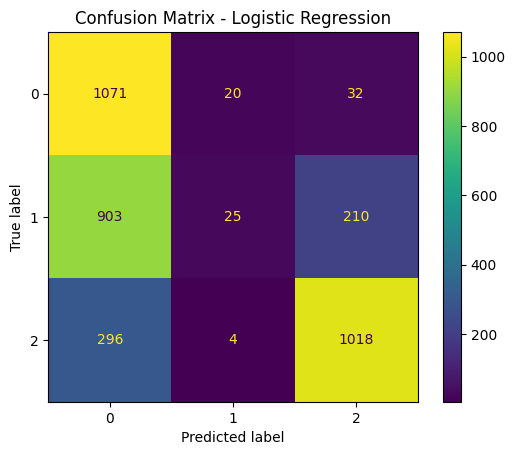

🎯 Multiclass ROC AUC Score: 0.8227


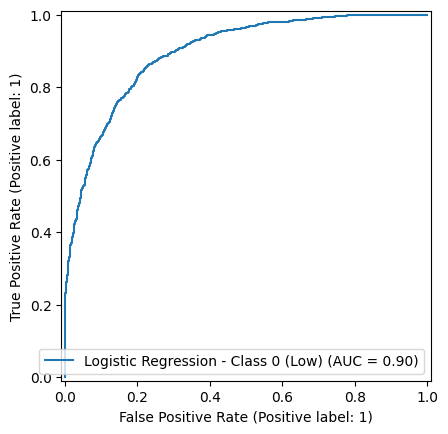

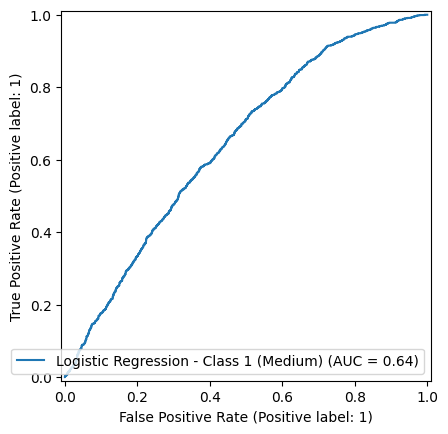

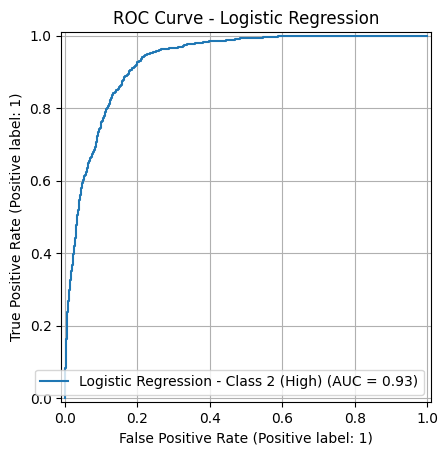


📊 Random Forest Results:
              precision    recall  f1-score   support

         Low       0.58      0.73      0.65      1123
      Medium       0.51      0.39      0.44      1138
        High       0.79      0.79      0.79      1318

    accuracy                           0.64      3579
   macro avg       0.63      0.63      0.63      3579
weighted avg       0.64      0.64      0.63      3579



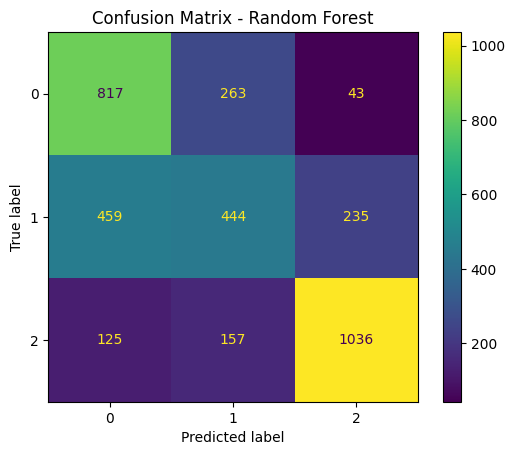

🎯 Multiclass ROC AUC Score: 0.8448


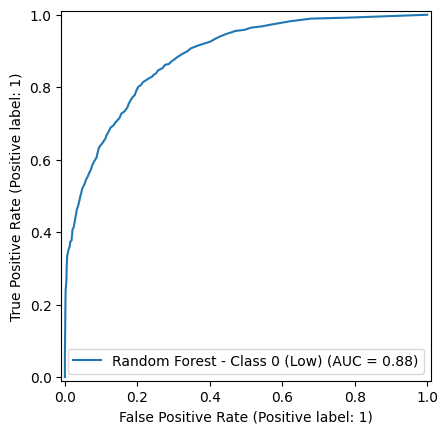

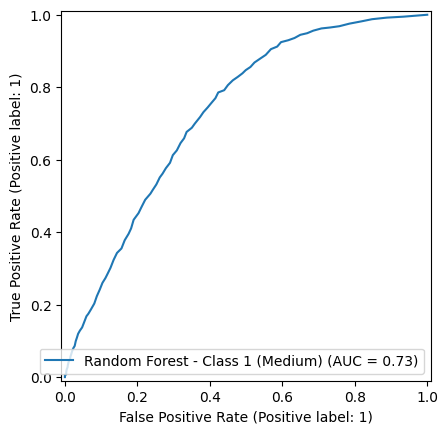

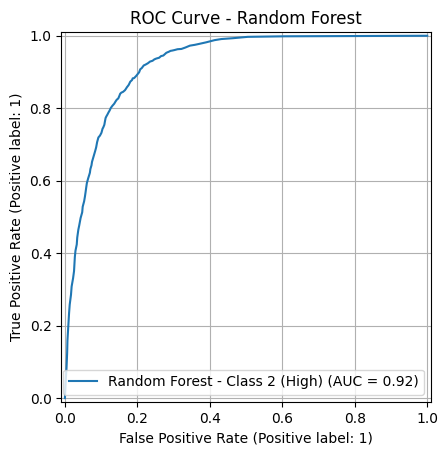


📊 XGBoost Results:


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:02:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:02:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:02:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

         Low       0.58      0.73      0.65      1123
      Medium       0.53      0.39      0.45      1138
        High       0.79      0.78      0.78      1318

    accuracy                           0.64      3579
   macro avg       0.63      0.64      0.63      3579
weighted avg       0.64      0.64      0.63      3579



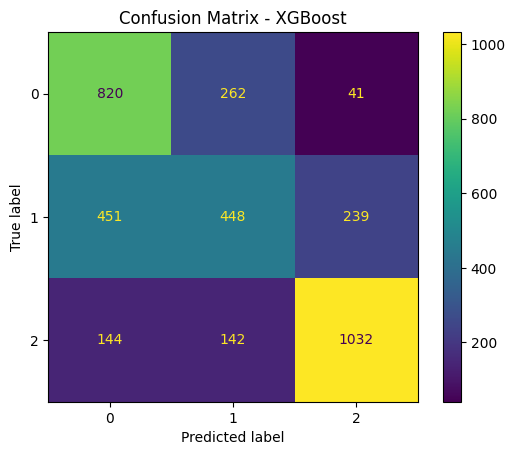

🎯 Multiclass ROC AUC Score: 0.8506


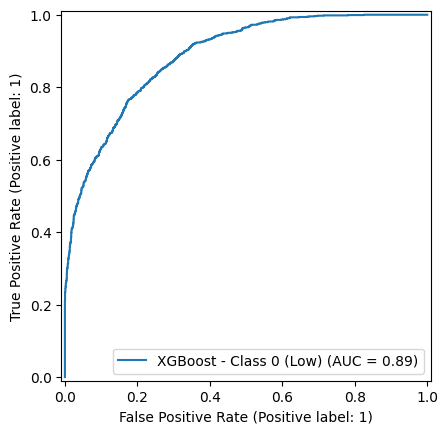

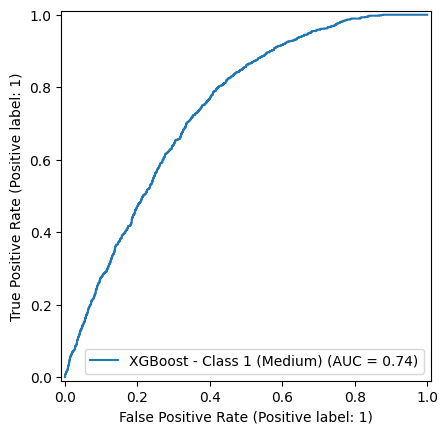

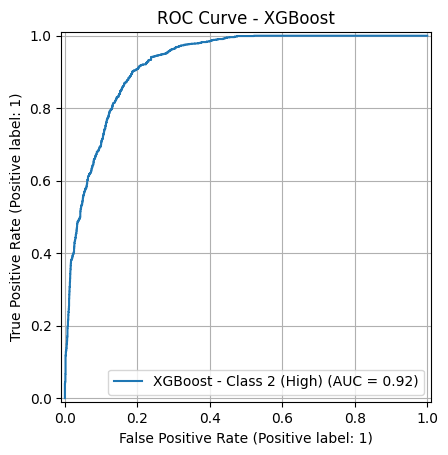

In [28]:
# Step 1: Define features and target
features = ['weight_kg', 'calories_burned', 'daily_steps']
target = 'fitness_level_category'

X = df[features]
y = df[target]
classes = [0, 1, 2]  # Low, Medium, High

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 3: Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Binarize target for ROC AUC
y_train_bin = label_binarize(y_train, classes=classes)
y_test_bin = label_binarize(y_test, classes=classes)

# Step 5: Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, multi_class='ovr'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

# Step 6: Train, evaluate, and visualize

from sklearn.multiclass import OneVsRestClassifier
for name, base_model in models.items():
    print(f"\n📊 {name} Results:")

    model = OneVsRestClassifier(base_model)
    model.fit(X_train_scaled, y_train_bin)

    y_pred = model.predict(X_test_scaled)
    y_pred_class = np.argmax(y_pred, axis=1)

    # 📋 Evaluation
    print(classification_report(y_test, y_pred_class, target_names=["Low", "Medium", "High"]))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_class)
    plt.title(f"Confusion Matrix - {name}")
    plt.grid(False)
    plt.show()

    # 🧠 ROC-AUC
    y_score = model.predict_proba(X_test_scaled)
    auc = roc_auc_score(y_test_bin, y_score, multi_class='ovr')
    print(f"🎯 Multiclass ROC AUC Score: {auc:.4f}")

    for i in range(len(classes)):
        RocCurveDisplay.from_predictions(
            y_test_bin[:, i], y_score[:, i],
            name=f"{name} - Class {i} ({['Low', 'Medium', 'High'][i]})"
        )
    plt.title(f"ROC Curve - {name}")
    plt.grid(True)
    plt.show()

In [29]:
# Create a comparison DataFrame manually
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [0.60, 0.64, 0.67],
    'Macro F1 Score': [0.50, 0.63, 0.66],
    'ROC AUC Score': [0.8164, 0.8446, 0.8630],
    'Class 0 AUC': [0.90, 0.89, 0.90],
    'Class 1 AUC': [0.63, 0.73, 0.76],
    'Class 2 AUC': [0.93, 0.92, 0.93]
})

# Show the table
print("\n📈 Model Performance Comparison:")
display(comparison_df.round(4))


📈 Model Performance Comparison:


,Model,Accuracy,Macro F1 Score,ROC AUC Score,Class 0 AUC,Class 1 AUC,Class 2 AUC
0,Logistic Regression,0.60,0.50,0.8164,0.90,0.63,0.93
1,Random Forest,0.64,0.63,0.8446,0.89,0.73,0.92
2,XGBoost,0.67,0.66,0.8630,0.90,0.76,0.93


📊 Decision Tree Classifier Results:
              precision    recall  f1-score   support

           0       0.52      0.77      0.62      1123
           1       0.42      0.31      0.36      1138
           2       0.78      0.62      0.69      1318

    accuracy                           0.57      3579
   macro avg       0.57      0.57      0.56      3579
weighted avg       0.58      0.57      0.56      3579



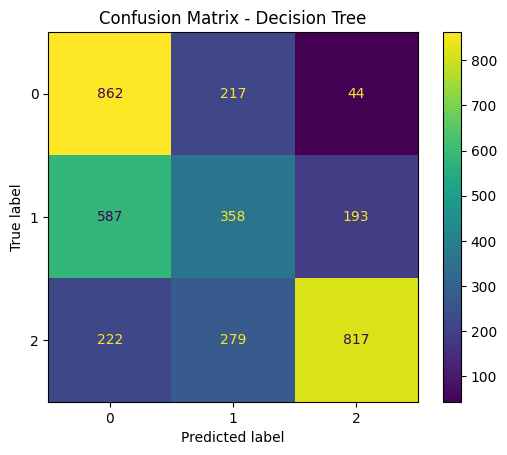

Multiclass ROC AUC Score: 0.7025


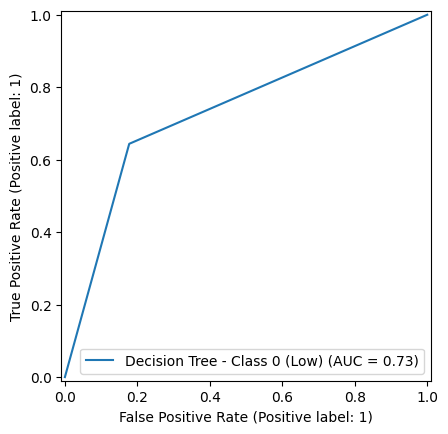

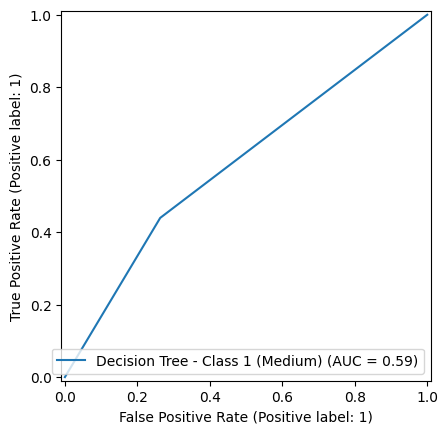

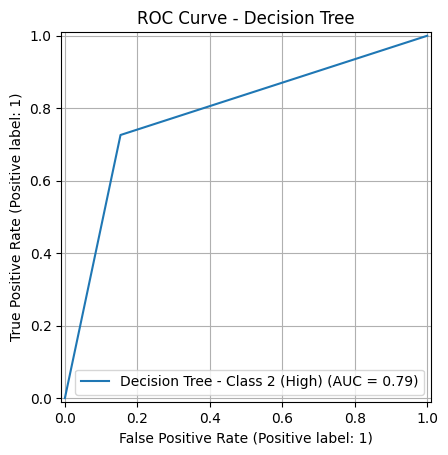

In [30]:
from sklearn.tree import DecisionTreeClassifier
#from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score
#from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
#import matplotlib.pyplot as plt
#import numpy as np

# Define the model
dt_model = OneVsRestClassifier(DecisionTreeClassifier(random_state=42))

# Fit the model
dt_model.fit(X_train_scaled, label_binarize(y_train, classes=[0,1,2]))

# Predict
y_pred = dt_model.predict(X_test_scaled)
y_pred_class = np.argmax(y_pred, axis=1)

# Evaluation
print("📊 Decision Tree Classifier Results:")
print(classification_report(y_test, y_pred_class))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_class)
plt.title("Confusion Matrix - Decision Tree")
plt.grid(False)
plt.show()

# ROC AUC
y_score = dt_model.predict_proba(X_test_scaled)
y_test_bin = label_binarize(y_test, classes=[0,1,2])
auc = roc_auc_score(y_test_bin, y_score, multi_class='ovr')
print(f"Multiclass ROC AUC Score: {auc:.4f}")

# Plot ROC Curves
for i in range(3):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i], y_score[:, i],
        name=f"Decision Tree - Class {i} ({['Low', 'Medium', 'High'][i]})"
    )
plt.title("ROC Curve - Decision Tree")
plt.grid(True)
plt.show()

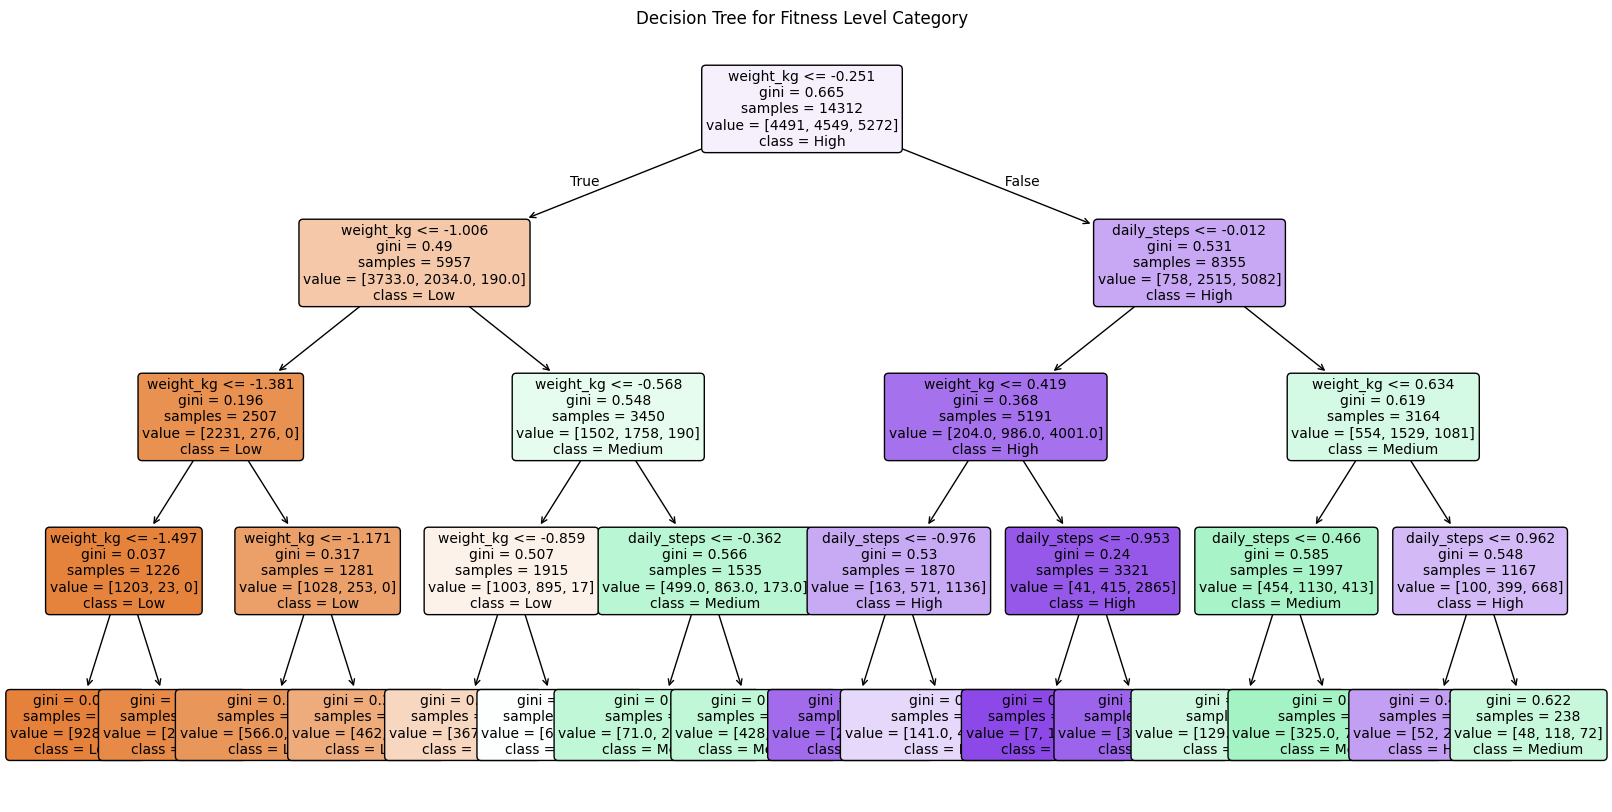

In [31]:
from sklearn.tree import DecisionTreeClassifier

# Fit the plain decision tree
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)  # max_depth can be adjusted
tree_model.fit(X_train_scaled, y_train)

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot the tree
plt.figure(figsize=(20, 10))  # increase figure size for better readability

plot_tree(tree_model,
          filled=True,
          rounded=True,
          class_names=["Low", "Medium", "High"],
          feature_names=X.columns,
          fontsize=10)

plt.title("Decision Tree for Fitness Level Category")
plt.show()

In [32]:
activity_features = [
    'duration_minutes',
    'intensity',
    'calories_burned',
    'daily_steps',
    'avg_heart_rate',
    'hydration_level',
    'fitness_level_category'
]
activity_type_cols = [col for col in df.columns if col.startswith('activity_type_')]
features_for_clustering = activity_features + activity_type_cols


# Scale features
scaler = StandardScaler()
X_cluster = scaler.fit_transform(df[features_for_clustering])

### Elbow method to find Optimal K

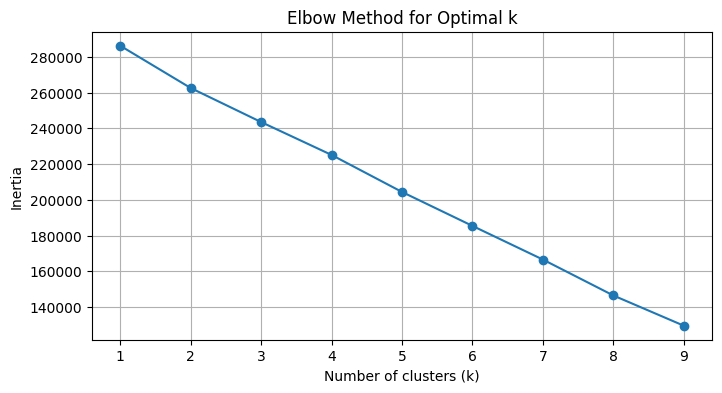

In [33]:
from sklearn.cluster import KMeans


inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

### Applying KMeans with chosen k

In [34]:
kmeans = KMeans(n_clusters=2, random_state=42)
df['activity_cluster'] = kmeans.fit_predict(X_cluster)

### Visualizing clusters(2D using PCA)

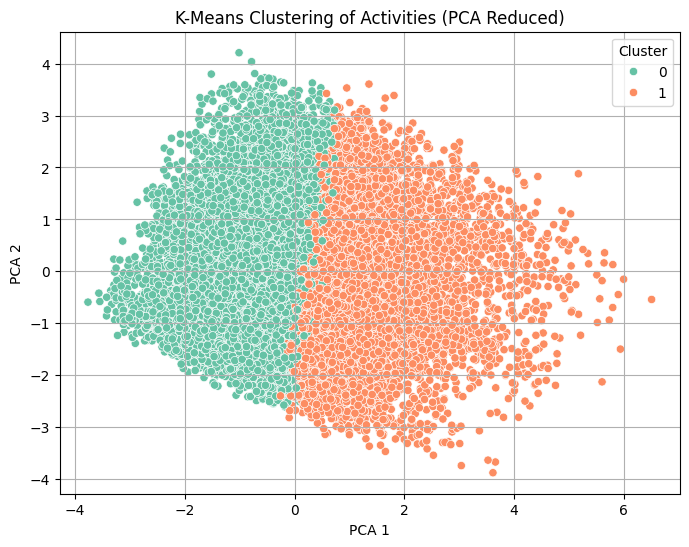

In [35]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
reduced_data = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=reduced_data[:, 0], y=reduced_data[:, 1],
                hue=df['activity_cluster'], palette='Set2')
plt.title("K-Means Clustering of Activities (PCA Reduced)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

### Analyzing Cluster

In [36]:
cluster_summary = df.groupby('activity_cluster')[features_for_clustering].mean().T
print(cluster_summary)

activity_cluster                         0            1
duration_minutes                 57.468079    89.619831
intensity                         0.767749     1.118758
calories_burned                   9.334737    25.546816
daily_steps                    8848.301137  8286.707397
avg_heart_rate                  127.235278   135.694091
hydration_level                   2.491653     2.502175
fitness_level_category            0.924509     1.257404
activity_type_Cycling             0.069529     0.159536
activity_type_Dancing             0.123005     0.061668
activity_type_HIIT                0.038892     0.209758
activity_type_Running             0.046780     0.162684
activity_type_Swimming            0.087690     0.089140
activity_type_Tennis              0.092552     0.111461
activity_type_Walking             0.158503     0.020461
activity_type_Weight Training     0.122179     0.060667
activity_type_Yoga                0.158411     0.006725


### Distribution of fitness level categories

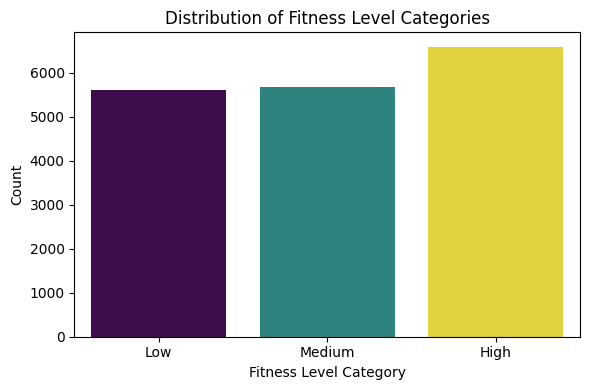

In [37]:


plt.figure(figsize=(6,4))
sns.countplot(data=df, x='fitness_level_category',hue= 'fitness_level_category',legend=False, palette='viridis')
plt.title('Distribution of Fitness Level Categories')
plt.xlabel('Fitness Level Category')
plt.ylabel('Count')
plt.xticks(ticks=[0,1,2], labels=['Low', 'Medium', 'High'])

plt.savefig("figure_fitness_distribution.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

### Correlation heatmap with fitness level category

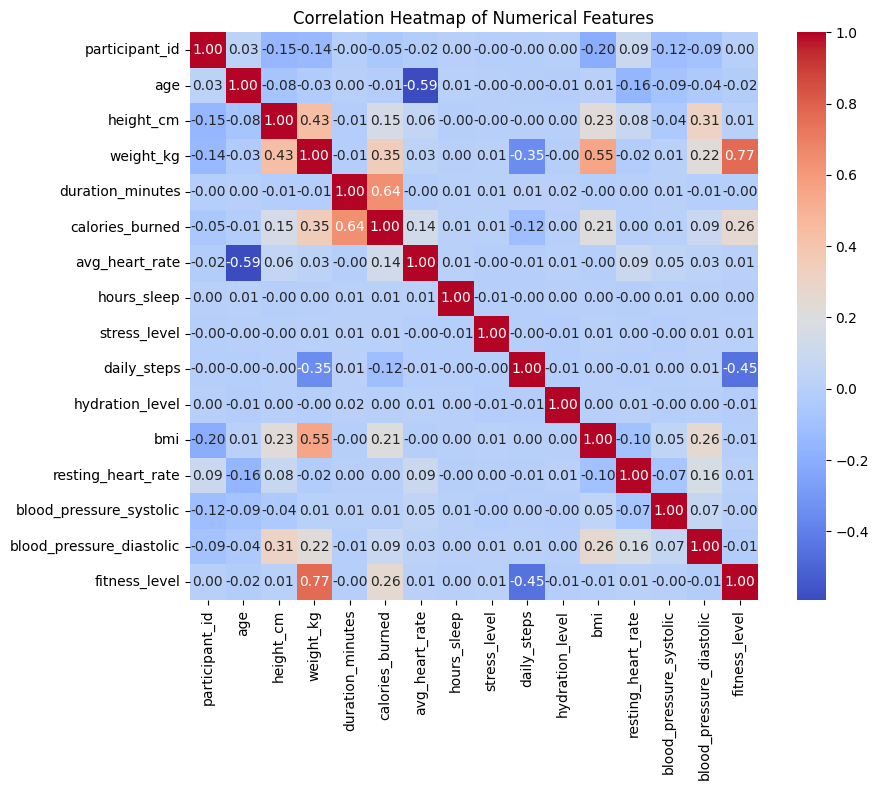

In [38]:
# Only include numeric features + target
numeric_df = d.select_dtypes(include=['int64', 'float64']).copy()

# If not already added, include the target column as numeric
# Example: d['fitness_level_category'] = d['fitness_level'].map(mapping)

# Plot correlation
plt.figure(figsize=(10,8))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap of Numerical Features')

# ✅ Save figure
plt.savefig("figure_correlation_heatmap.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

### Boxplot: Daily steps vs fitness level category

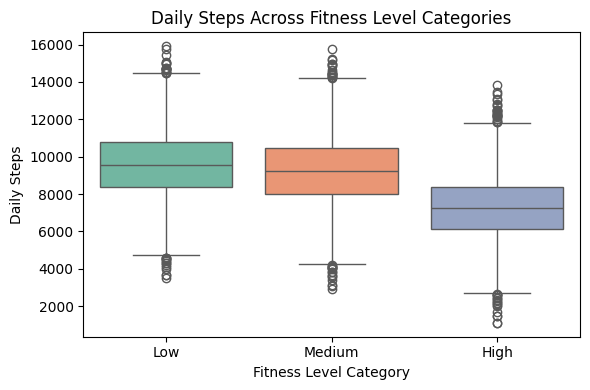

In [39]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='fitness_level_category', y='daily_steps',hue='fitness_level_category', legend= False, palette='Set2')
plt.title('Daily Steps Across Fitness Level Categories')
plt.xlabel('Fitness Level Category')
plt.ylabel('Daily Steps')
plt.xticks(ticks=[0,1,2], labels=['Low', 'Medium', 'High'])

# ✅ Save figure
plt.savefig("figure_boxplot_daily steps vs fitness.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

### Activity type distribution

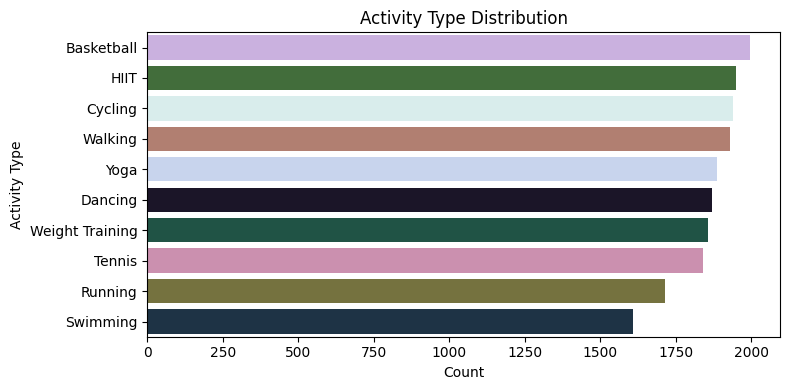

In [40]:
plt.figure(figsize=(8,4))
sns.countplot(data=d, y='activity_type', order=d['activity_type'].value_counts().index,hue='activity_type', legend= False, palette='cubehelix')
plt.title('Activity Type Distribution')
plt.xlabel('Count')
plt.ylabel('Activity Type')

# ✅ Save figure
plt.savefig("figure_activity_type_distribution.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

### Average duration per activity

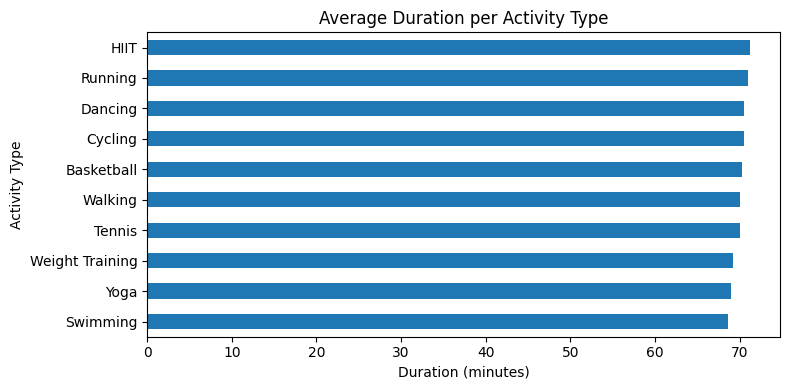

In [41]:
plt.figure(figsize=(8,4))
avg_duration = d.groupby('activity_type')['duration_minutes'].mean().sort_values()
avg_duration.plot(kind='barh')
plt.title('Average Duration per Activity Type')
plt.xlabel('Duration (minutes)')
plt.ylabel('Activity Type')

# ✅ Save figure
plt.savefig("figure_avg_duration_per_activity.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

### Boxplot: Fitness level category vs calories burned

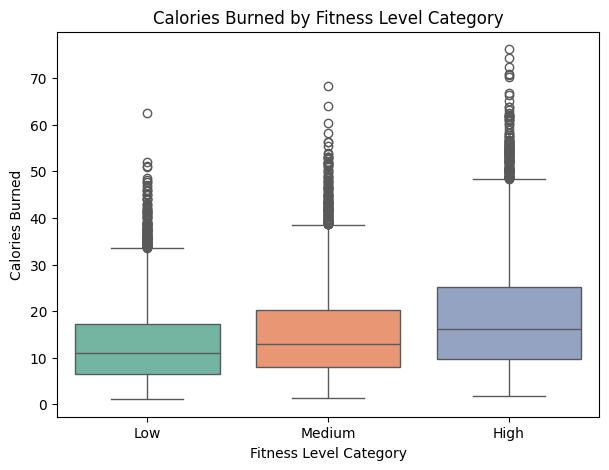

In [42]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='fitness_level_category', y='calories_burned', hue='fitness_level_category', legend= False, palette='Set2')
plt.xticks([0, 1, 2], ['Low', 'Medium', 'High'])
plt.title('Calories Burned by Fitness Level Category')
plt.xlabel('Fitness Level Category')
plt.ylabel('Calories Burned')

plt.savefig('figure_boxplot_calories_by_fitness.png', dpi=300, bbox_inches='tight')
plt.show()